# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
**Actividad Curvas ROC y PR**


# **Itroducción**

La actividad se basa en los datos conocidos como "oil-spill" (derrame de petróleo).

El archivo de los datos está en Canvas y se llama "oil-spill.csv".


En la siguiente liga se encuentra la liga del artículo relacionado a dicha base de datos. Los datos incluyen 50 columnas y 937 registros. Las primeras 49 columnas son métricas obtenidas de imágenes satelitales del océano, en algunas de las cuales se tiene petróleo que fue derramado por alguna fuente desconocida. En el artículo se describe a detalle la manera en que se obtuvieron dichas columnas. Para la actividad es suficiente considerarlas como de valor numérico. La última columna es de valor 1 (hay derrame en esa sección de la imagen) o 0 (no hay derrame en esa sección de la imagen).

https://webdocs.cs.ualberta.ca/~holte/Publications/oilspill.pdf

En la siguiente liga puedes encontrar información de varias de las métricas que estaremos utilizando:

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

La media geométrica se puede obtener combinando las métricas anteriores, pero para fines prácticos usaremos la de la librería llamada "imbalanced-learn":

https://glemaitre.github.io/imbalanced-learn/generated/imblearn.metrics.geometric_mean_score.html

In [19]:
# Incluye todas las librerías que consideres adecuadas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer
from imblearn.metrics import geometric_mean_score
from numpy import mean, std
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import classification_report

Para fines de la actividad procesaremos los datos de manera estándar para concentrarnos en los temas de la actividad.

In [20]:
path = 'oil_spill.csv'
df = read_csv(path, header=None)   # no tienen nombre las columnas

print('Timensión del DataFrame',df.shape)

# eliminamos las siguientes columnas:
df.drop(22, axis=1, inplace=True)    # Esta columna tiene un solo valor constante.
df.drop(0, axis=1, inplace=True)     # Esta columna contiene información de secciones (batches) de las imágenes, que no la requerimos.

df.columns = [i for i in range(df.shape[1])]   # Renombramos las columnas para que sean enteros consecutivos.

# Particionamos los datos de entrada (X) y de salida (y):
X,y = df.iloc[:,:-1], df.iloc[:,-1]

Xtv, Xtest, ytv, ytest = train_test_split(X, y, test_size=0.12, stratify=y, shuffle=True, random_state=0)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv, test_size=0.2, shuffle=True, random_state=5)
print('\nPartición:')
print('Train: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (ytrain.sum(), 100*(ytrain.sum() / len(ytrain))))
print('Val: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (yval.sum(), 100*(yval.sum() / len(yval))))
print('Test: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (ytest.sum(), 100*(ytest.sum() / len(ytest))))

Timensión del DataFrame (937, 50)

Partición:
Train: Conteo clase positiva=29, Porcentaje=4.40%
Val: Conteo clase positiva=7, Porcentaje=4.24%
Test: Conteo clase positiva=5, Porcentaje=4.42%


Breve descripción numérica y gráfica del conjunto de entrenamiento:

In [21]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
0,659.0,344.153263,1.880555e+03,10.00,22.000,65.00,134.500,28526.00
1,659.0,709.286161,5.993162e+02,1.95,97.475,727.45,1242.135,1893.08
2,659.0,867.791608,5.145066e+02,1.00,445.065,791.35,1243.220,2674.16
3,659.0,85.078907,4.573682e+01,0.00,55.000,74.00,119.000,180.00
4,659.0,824339.418816,4.131627e+06,70312.00,127500.000,187500.00,348750.000,71315000.00
5,659.0,42.966449,1.259403e+01,21.24,33.430,39.64,51.975,82.64
6,659.0,9.162307,3.587007e+00,0.83,6.920,8.22,10.755,24.28
7,659.0,4119.098634,8.899523e+03,667.00,1404.750,2167.00,3600.000,160740.00
8,659.0,0.222898,8.984421e-02,0.02,0.170,0.21,0.260,0.74
9,659.0,110.288771,6.272348e+01,47.00,82.950,99.80,115.700,901.70


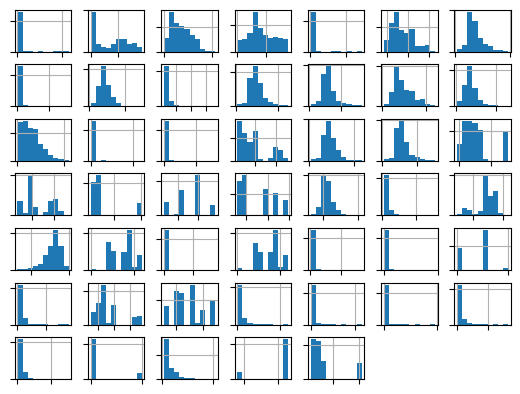

In [22]:
ax = Xtrain.hist()  # Histogramas:
# Quitemos toda la información del gráfico para visualizarlo de manera sencilla:
for axis in ax.flatten():
  axis.set_title('')
  axis.set_xticklabels([])
  axis.set_yticklabels([])
plt.show()

In [23]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 659 entries, 770 to 460
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       659 non-null    int64  
 1   1       659 non-null    float64
 2   2       659 non-null    float64
 3   3       659 non-null    int64  
 4   4       659 non-null    float64
 5   5       659 non-null    float64
 6   6       659 non-null    float64
 7   7       659 non-null    float64
 8   8       659 non-null    float64
 9   9       659 non-null    float64
 10  10      659 non-null    float64
 11  11      659 non-null    float64
 12  12      659 non-null    float64
 13  13      659 non-null    float64
 14  14      659 non-null    float64
 15  15      659 non-null    float64
 16  16      659 non-null    float64
 17  17      659 non-null    float64
 18  18      659 non-null    float64
 19  19      659 non-null    float64
 20  20      659 non-null    float64
 21  21      659 non-null    float64
 22  22   

In [24]:
# Código-1:
# Aplicamos la función Dummy:

def evaluate_model(X, y, model):
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
  metric = make_scorer(geometric_mean_score)
  scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
  return scores


modeloD = DummyClassifier(strategy='uniform')
scores = evaluate_model(X, y, modeloD)

print('Métrica G-mean - Media Geométrica: %.3f (%.3f)' % (mean(scores), std(scores)))

Métrica G-mean - Media Geométrica: 0.469 (0.161)


# **Ejercicio-1**

### **Explica lo que hace cada línea de código de la celda anterior llamada "Código-1", así como lo que significa el valor que se obtiene en su salida:**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



1.   Se define la función evaluate_model(X, y, model) que se encarga de evaluar un modelo de clasificación usando validación cruzada repetida.
2.   Se configura la validación cruzada en la que se usa RepeatedStratifiedKFold, que genera múltiples particiones estratificadas de los datos. La estratificación asegura que la distribución de clases en cada pliegue sea similar a la original, lo que es crucial en problemas con clases desbalanceadas.
3.   Definición de la métrica de evaluación make_scorer donde convierte la métrica geometric_mean_score en un formato compatible con cross_val_score. La media geométrica (G-mean) es importante cuando se trabaja con datos desbalanceados, ya que penaliza los errores en ambas clases de manera equitativa, a diferencia de la precisión tradicional, que puede ser sesgada hacia la clase mayoritaria.
4.   Se Calcula la métrica G-mean en validación cruzada en esta linea se aplica la validación cruzada al modelo especificado. Se calcula G-mean en cada iteración, generando una distribución de puntajes en lugar de una única medición.
5.   Indicación del retorno de los puntajes de la función, que contiene los valores de G-mean para cada una de las iteraciones. Este conjunto de valores permite evaluar la estabilidad del modelo y estimar su desempeño medio y variabilidad.
6.   En esta línea se genera la creación del modelo Dummy que es un modelo base que clasifica de manera aleatoria con igual probabilidad entre las clases con una estrategía uniforme. Su propósito no es realizar predicciones útiles, sino establecer un punto de referencia mínimo
7.   Aquí se llama a la función evaluate_model para medir el desempeño del DummyClassifier utilizando validación cruzada. En este casi divide los datos en 10 subconjuntos, entrena el modelo en 9 y evalúa en el restante, repitiendo esto 3 veces para reducir la variabilidad de los resultados.
8.   Imprime el promedio y la desviación estandar de los porcentajes resultantes, de esta manera resumiendo el rendimiento del modelo en términos de rendimiento media y variabilidad.
9.   Significado del valor de salida: Métrica G-mean - Media Geométrica: 0.503 (0.117) El resultado indica que el modelo tiene un desempeño cercano al azar. El valor 0.503 es el promedio de la métrica G-mean en la validación cruzada, lo que sugiere que el DummyClassifier no identifica patrones reales y clasifica de forma aleatoria. La desviación estándar 0.117 refleja la variabilidad entre iteraciones, mostrando que los resultados fluctúan dependiendo de la partición de datos utilizada.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

Para fines de esta actividad definimos las siguientes transformaciones del preprocesamiento de los datos:

In [25]:
# Transforamaciones numéricas:

numericas_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='mean')),
                                       ('std_transformer', StandardScaler())])
numericas_pipeline_nombres = Xtrain.columns

columnasTransformer = ColumnTransformer(transformers = [('num', numericas_pipeline, numericas_pipeline_nombres)],
                                        remainder='passthrough')

In [26]:
mi_metrica = make_scorer(geometric_mean_score)  # definimos la métrica G-mean

Resultados de Validación:
LR
Exactitud: >> 0.951 (0.015)
G-mean: >> 0.741 (0.079)

LASSO
Exactitud: >> 0.968 (0.009)
G-mean: >> 0.689 (0.104)

RIDGE
Exactitud: >> 0.969 (0.011)
G-mean: >> 0.725 (0.108)

EN
Exactitud: >> 0.968 (0.010)
G-mean: >> 0.694 (0.112)

kNN
Exactitud: >> 0.966 (0.005)
G-mean: >> 0.464 (0.204)



<ipython-input-27-0db74e03d2d4>:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados1, labels=nombres,  showmeans=True)


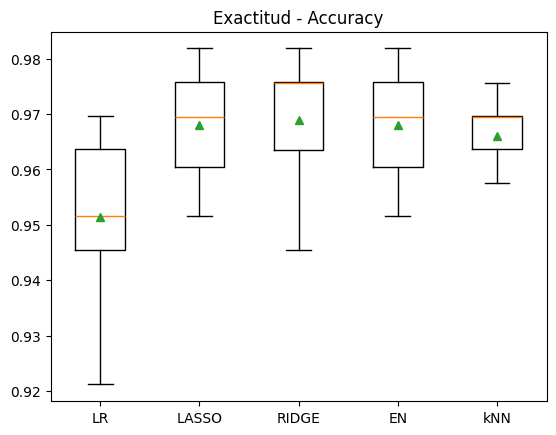

<ipython-input-27-0db74e03d2d4>:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados2, labels=nombres,  showmeans=True)


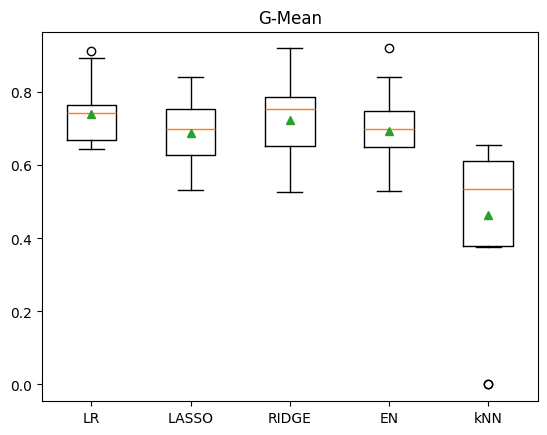

In [27]:
# Código-2:
# ACCURACY & G-mean

def mis_modelos1():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None,
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')


  modelos.append(LogisticRegression(penalty='l1',
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')


  modelos.append(LogisticRegression(penalty='l2',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet',
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')

  return modelos, nombres

# +++++++++++++++++++++++++++++++


modelos, nombres = mis_modelos1()
resultados1, resultados2 = list(), list()
print('Resultados de Validación:')

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'exactitud':'accuracy', 'm_geo':mi_metrica},
                          cv=cv1)

  resultados1.append(scores['test_exactitud'])
  resultados2.append(scores['test_m_geo'])

  print(nombres[i])
  print('Exactitud: >> %.3f (%.3f)' % (np.nanmean(scores['test_exactitud']), np.nanstd(scores['test_exactitud'])))
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
  print()

plt.boxplot(resultados1, labels=nombres,  showmeans=True)
plt.title("Exactitud - Accuracy")
plt.show()

plt.boxplot(resultados2, labels=nombres,  showmeans=True)
plt.title("G-Mean")
plt.show()


# **Ejercicio-2**

### **Explica por qué la salida y gráficos anteriores nos ayudan a respaldar la decisión de usar la métrica G-mean, en lugar de la exactitud (accuracy) en este problema:**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



En este problema, la métrica G-mean es más adecuada que la exactitud porque permite evaluar de mejor manera el desempeño del modelo en un conjunto de datos desbalanceado.

Observando los resultados obtenidos, se nota que los valores de exactitud son consistentemente altos para todos los modelos, con valores que oscilan entre 0.951 y 0.969. Sin embargo, la G-mean varía significativamente, con valores que van desde 0.464 (kNN) hasta 0.741 (LR).

Esto ocurre porque la exactitud solo mide el porcentaje total de predicciones correctas sin distinguir entre clases. Si el conjunto de datos tiene un desbalance de clases, un modelo puede obtener una alta exactitud simplemente prediciendo siempre la clase mayoritaria, sin aprender realmente a distinguir la clase minoritaria.

En cambio, la G-mean es útil en estos casos porque considera el equilibrio entre la sensibilidad (capacidad de identificar correctamente la clase positiva) y la especificidad (capacidad de identificar correctamente la clase negativa). Valores bajos en G-mean, como el 0.464 obtenido por kNN, indican que el modelo tiene problemas para clasificar correctamente la clase minoritaria, a pesar de tener una exactitud alta.

Por lo tanto, los resultados respaldan el uso de G-mean como métrica principal en lugar de la exactitud, ya que refleja mejor el rendimiento del modelo en un problema de clasificación con clases desbalanceadas.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

# **Ejercicio-3**

### **Utilizando en adelante solamente la métrica G-mean y de manera análoga al código de la celda llamada "Código-2" anterior, define una función llamada "mis_modelos2()" y utilízala para definir los mismos modelos de regresión logística, pero incluyendo el argumento class_weight='balanced'. Los demás hiperparámetros los puedes variar si así lo consideras adecuado. Incluye kNN, aunque no tiene argumento para balanceo de las clases de salida.**

Resultados de Validación (G-mean):
LR-Balanced -> G-mean: 0.678 (0.118)
LASSO-Balanced -> G-mean: 0.849 (0.069)
RIDGE-Balanced -> G-mean: 0.852 (0.070)
EN-Balanced -> G-mean: 0.851 (0.070)
kNN -> G-mean: 0.464 (0.204)


<ipython-input-28-7d4410f0fa5c>:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados2, labels=nombres2,  showmeans=True)   # gráficos de caja para una comparación visual de los resultados.


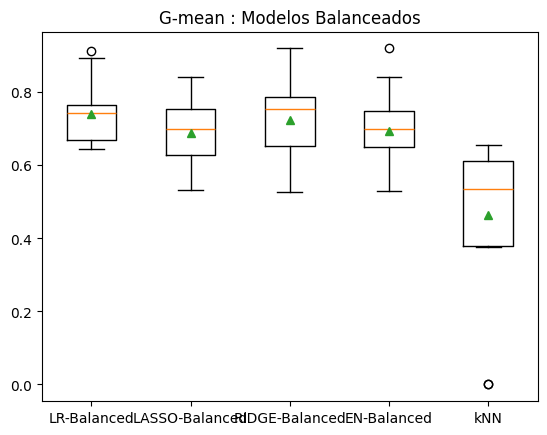

In [28]:
#  Casos balancedos con hiperparámetro de Regresión Logística:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

def mis_modelos2():
    modelos, nombres = list(), list()

    modelos.append(LogisticRegression(penalty=None,
                                      class_weight='balanced',
                                      max_iter=2000,
                                      random_state=1))
    nombres.append('LR-Balanced')

    modelos.append(LogisticRegression(penalty='l1',
                                      solver='liblinear',
                                      class_weight='balanced',
                                      max_iter=2000,
                                      random_state=1))
    nombres.append('LASSO-Balanced')

    modelos.append(LogisticRegression(penalty='l2',
                                      class_weight='balanced',
                                      max_iter=2000,
                                      random_state=1))
    nombres.append('RIDGE-Balanced')

    modelos.append(LogisticRegression(penalty='elasticnet',
                                      l1_ratio=0.5,
                                      solver='saga',
                                      class_weight='balanced',
                                      max_iter=5000,
                                      random_state=1))
    nombres.append('EN-Balanced')

    modelos.append(KNeighborsClassifier(n_neighbors=5))
    nombres.append('kNN')

    return modelos, nombres

# Obtener modelos y nombres
modelos2, nombres2 = mis_modelos2()

resultados_gmean = list()
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

print("Resultados de Validación (G-mean):")
for i in range(len(modelos2)):
    pipeline = Pipeline(steps=[('ct', columnasTransformer), ('m', modelos2[i])])
    scores = cross_validate(pipeline,
                            Xtv,
                            np.ravel(ytv),
                            scoring={'m_geo': mi_metrica},
                            cv=cv)

    gmean_mean = np.nanmean(scores['test_m_geo'])
    gmean_std = np.nanstd(scores['test_m_geo'])
    resultados_gmean.append(scores['test_m_geo'])

    print(f"{nombres2[i]} -> G-mean: {gmean_mean:.3f} ({gmean_std:.3f})")

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


plt.boxplot(resultados2, labels=nombres2,  showmeans=True)   # gráficos de caja para una comparación visual de los resultados.
plt.title("G-mean : Modelos Balanceados")
plt.show()

# **Ejercicio-4**

### **4a) Selecciona el que consideres sea el mejor modelo encontrado hasta ahora y utilízalo para obtener los gráficos curva-ROC y curva-PR, así como los valores de sus áreas bajo la curva. Sigue utilizando los conjuntos de entrenamiento y validación.**



<Figure size 600x600 with 0 Axes>

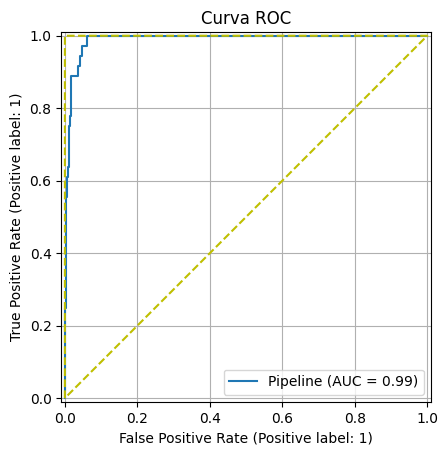

<Figure size 600x600 with 0 Axes>

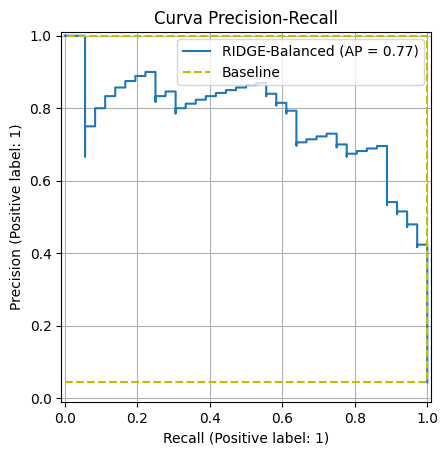

In [29]:
# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.
# RIDGE
mejor_modelo = LogisticRegression(penalty='l2',
                                  max_iter=2000,
                                  class_weight='balanced',
                                  random_state=1)

# Pipeline con preprocesamiento
pipeline = Pipeline(steps=[('ct', columnasTransformer), ('m', mejor_modelo)])

pipeline.fit(Xtv, np.ravel(ytv))


#Gráfica de la CURVA ROC con AUC
plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(pipeline, Xtv, ytv)  # Generar curva ROC
plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.title('Curva ROC')
plt.grid()
plt.show()

# Gráfica de la CURVA PR con AUC
plt.figure(figsize=(6, 6))
PrecisionRecallDisplay.from_estimator(pipeline, Xtv, ytv, name="RIDGE-Balanced")  # Generar curva PR

tasa_positiva = ytv.mean()  # Proporción de positivos en el dataset
plt.plot([0, 1, 1, 0], [tasa_positiva, tasa_positiva, 1, 1], 'y--', label="Baseline")
plt.legend(loc="upper right")

plt.title('Curva Precision-Recall')
plt.grid()
plt.show()

# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### **4b) Incluye tus conclusiones de los gráficos obtenidos en el inciso anterior.**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



El modelo evaluado muestra un desempeño sobresaliente en términos de discriminación entre clases, con un AUC (Área Bajo la Curva ROC) de 0.99. Este valor cercano a 1 indica que el modelo tiene una capacidad casi perfecta para distinguir entre la clase positiva y negativa, lo que sugiere que, en términos generales, es altamente eficaz para realizar predicciones precisas. La curva ROC obtenida refleja esta capacidad, mostrando una forma pronunciada hacia la esquina superior izquierda del gráfico, lo que significa que el modelo logra una alta tasa de verdaderos positivos sin incrementar significativamente la tasa de falsos positivos. Sin embargo, aunque el AUC es excelente, la métrica de Average Precision (AP) presenta un valor de 0.77, lo que indica un rendimiento menor al evaluar la relación entre precisión y recall.

La curva Precision-Recall (PR) muestra ciertas fluctuaciones a lo largo de sus valores, lo que sugiere que el modelo no mantiene una precisión completamente estable al predecir la clase positiva. Esto puede ser una señal de que, si bien el modelo identifica correctamente muchas instancias positivas, en algunas regiones del conjunto de datos su desempeño es más variable. Este comportamiento se relaciona con problemas con clases desbalanceadas, donde el modelo puede verse influenciado por la dominancia de la clase mayoritaria. El hecho de que el AP no sea tan alto como el AUC sugiere que, aunque el modelo es muy efectivo en la clasificación general, puede haber áreas donde no captura de manera consistente los positivos, afectando la precisión en ciertos umbrales de recall.

Para abordar este desafío se podrían ajustar hiperparámetros del modelo o explorar diferentes arquitecturas podría mejorar la estabilidad en la predicción de la clase positiva y con ello tener un mejor rendimiento.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

# **Ejercicio-5**

### **Utiliza el conjunto de prueba (test) para evaluar el mejor modelo obtenido.**

<Figure size 600x600 with 0 Axes>

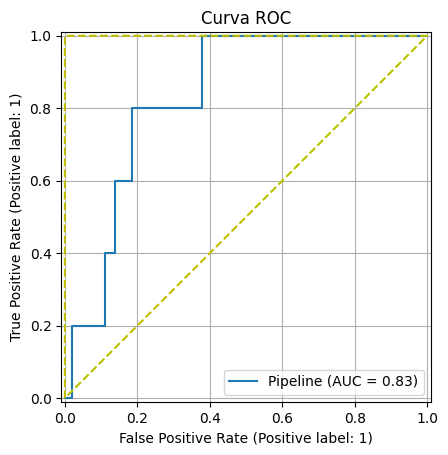

<Figure size 600x600 with 0 Axes>

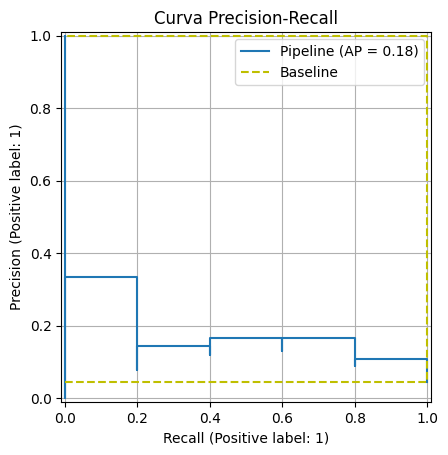

AUC (Área bajo la curva ROC): 0.8333
AP (Área bajo la curva Precision-Recall): 0.1836
G-Mean (Media Geométrica): 0.4260

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9608    0.9074    0.9333       108
           1     0.0909    0.2000    0.1250         5

    accuracy                         0.8761       113
   macro avg     0.5258    0.5537    0.5292       113
weighted avg     0.9223    0.8761    0.8976       113



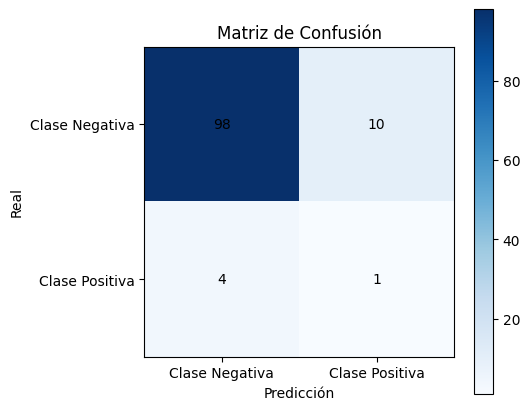

In [31]:
# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.
mejor_modelo = LogisticRegression(penalty='l2',
                                  max_iter=2000,
                                  class_weight='balanced',
                                  random_state=1)

# Pipeline con preprocesamiento
pipeline = Pipeline(steps=[('ct', columnasTransformer), ('m', mejor_modelo)])

# Entrenar el modelo con el conjunto de entrenamiento
pipeline.fit(Xtrain, np.ravel(ytrain))

# Predicciones con el conjunto de prueba
ytest_pred = pipeline.predict(Xtest)
ytest_pred_proba = pipeline.predict_proba(Xtest)[:, 1]  # Probabilidades para calcular AUC

# Curva ROC con AUC
plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(pipeline, Xtest, ytest)  # Generar curva ROC
plt.plot([0,0,1,0],[0,1,1,0], 'y--')
plt.title('Curva ROC')
plt.legend()
plt.grid()
plt.show()

# Curva Precision-Recall con AUC
plt.figure(figsize=(6, 6))
PrecisionRecallDisplay.from_estimator(pipeline, Xtest, ytest)  # Generar curva PR
tasa_positiva = ytv.mean()  # Proporción de positivos en el dataset
plt.plot([0, 1, 1, 0], [tasa_positiva, tasa_positiva, 1, 1], 'y--', label="Baseline")
plt.legend(loc="upper right")
plt.title('Curva Precision-Recall')
plt.grid()
plt.show()

# AUC Área bajo la curva ROC
auc = roc_auc_score(ytest, ytest_pred_proba)
print(f'AUC (Área bajo la curva ROC): {auc:.4f}')

# AP Área bajo la curva Precision-Recall
ap = average_precision_score(ytest, ytest_pred_proba)
print(f'AP (Área bajo la curva Precision-Recall): {ap:.4f}')

#G-mean
g_mean = geometric_mean_score(ytest, ytest_pred)
print(f'G-Mean (Media Geométrica): {g_mean:.4f}')

# Métricas adicionales: Recall, Precision y F1-Score
print("\nReporte de clasificación:")
print(classification_report(ytest, ytest_pred, digits=4))

# Matriz de confusión
conf_matrix = confusion_matrix(ytest, ytest_pred)

plt.figure(figsize=(5, 5))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks([0, 1], labels=['Clase Negativa', 'Clase Positiva'])
plt.yticks([0, 1], labels=['Clase Negativa', 'Clase Positiva'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')

# Anotar los valores en la matriz de confusión
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color='black')

plt.show()
# **+++++++++++ Termina sección para agregar código ++++++++++++++**

# **Ejercicio-6**

### **Incluye tus conclusiones finales de los resultados obtenidos y de la actividad en general.**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**



Este ejercicio me permitió darme cuenta de lo importante que es el balance de datos en el aprendizaje automático, algo que nunca había tomado en cuenta antes. Al revisar los resultados, vi que el modelo tuvo un buen desempeño en la clase mayoritaria (0), con una precisión del 96.08 % y un recall del 90.74 %. Sin embargo, en la clase minoritaria (1), la precisión cayó a solo un 9.09 % y el recall a un 20.00 %, lo que demuestra que el modelo tiene muchas dificultades para identificar correctamente los casos positivos por la situación del desbalanceo.

El AUC-ROC de 0.8333 indica que el modelo tiene una capacidad razonable para diferenciar entre clases, pero el Average Precision (AP) de apenas 0.1836 me dejó claro que el rendimiento en la detección de la clase minoritaria es muy bajo. Además, con 10 falsos positivos y 4 falsos negativos, 98 verdaderos negativos y solo 1 verdadero positivo, quedó evidente que el modelo se inclina demasiado hacia la clase mayoritaria que es la negativa, lo que lo hace poco útil en un contexto donde detectar los casos positivos es clave como en este caso de oil spills.

Algo que me pareció muy interesante es cómo el modelo y las métricas, de cierta manera, se ven "recompensados" por predecir siempre la clase con mayor representación en los datos, lo que refuerza la idea de que un mal conjunto de datos puede llevar a malos resultados (garbage in, garbage out). Si los datos no están bien distribuidos o no reflejan adecuadamente el problema, el modelo simplemente no tiene con qué aprender bien. Esto me hizo reflexionar sobre la importancia de la recolección de datos y de técnicas que ayuden a mejorar el balance, como el sobremuestreo (SMOTE), el submuestreo o ajustar los pesos de las clases en la función de pérdida.

Durante la actividad, también exploré diferentes métricas más allá de la precisión general, como G-mean, la curva ROC, la curva Precision-Recall, el AUC y el AP, lo que me ayudó a tener una visión más completa del rendimiento del modelo. Además, probé con una regresión logística con balanceo de clases, lo que mejoró un poco los resultados, pero sigue habiendo margen de mejora.

En general, me pareció una actividad muy interesante y me ayudó a entender que entrenar un modelo no es solo aplicar un algoritmo, sino que hay que analizar bien los datos, elegir las métricas adecuadas y probar distintas estrategias para mejorar el rendimiento. Sin duda, me llevo una mejor comprensión de los retos que implica trabajar con datos desbalanceados y de cómo enfrentarlos en futuros proyectos.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

## **<<< Fin de la Actividad de la Semana - curvas ROC y PR >>>**